1. Đang nạp và xử lý dữ liệu...
2. Đang Tuning tìm siêu tham số tối ưu (Quá trình này mất khoảng 2-3 phút)...



,Mô hình,MAE,RMSE,R² Score
0,Linear Regression,2535.243003,3075.489292,0.247237
1,XGBoost (Tối ưu),2535.372439,3081.523955,0.244280
2,Random Forest (Tối ưu),2551.627106,3108.654519,0.230914



Tham số vô địch của Random Forest: {'n_estimators': 200, 'max_depth': 10}


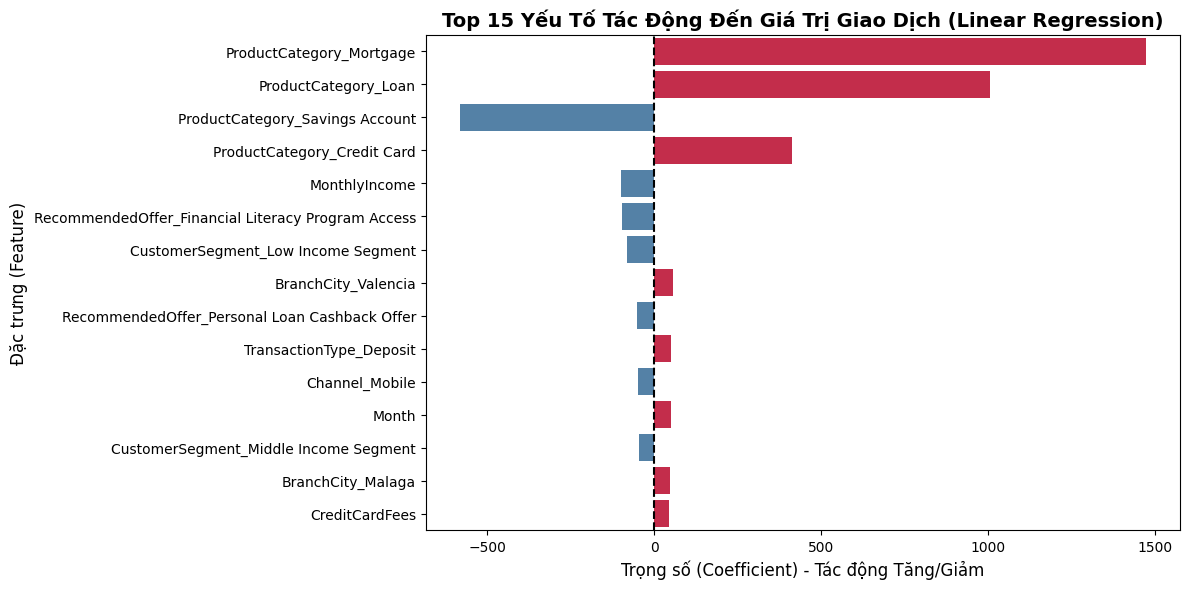


--- PHƯƠNG TRÌNH HỒI QUY (Minh họa Top 3 đặc trưng) ---
Amount = 5042.08 + 1470.99 * ProductCategory_Mortgage + 1005.42 * ProductCategory_Loan - 581.66 * ProductCategory_Savings Account + ...


In [ ]:
#MỨC 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo để kết quả hiển thị gọn gàng


# BƯỚC 1 & 2: NẠP DỮ LIỆU & FEATURE ENGINEERING

print("1. Đang nạp và xử lý dữ liệu...")
file_path = '/content/Banking_Transactional_Dataset.xlsx'
df = pd.read_excel(file_path)

# Trích xuất đặc trưng thời gian
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

# Loại bỏ các cột không có giá trị dự báo
cols_to_drop = ['TransactionID', 'CustomerID', 'TransactionDate', 'BranchLat', 'BranchLong', 'Currency']
df_ml = df.drop(columns=cols_to_drop)


# BƯỚC 3 & 4: ENCODING & TRAIN/TEST SPLIT

X = df_ml.drop(columns=['Amount'])
y = df_ml['Amount'] # Giữ nguyên gốc, KHÔNG dùng np.log1p

# Mã hóa One-Hot cho các cột dạng chữ
X_encoded = pd.get_dummies(X, drop_first=True)

# Chia tập dữ liệu 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


# BƯỚC 5: DATA SCALING (CHUẨN HÓA THANG ĐO)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# BƯỚC 6: CROSS VALIDATION & HYPERPARAMETER TUNING

print("2. Đang Tuning tìm siêu tham số tối ưu (Quá trình này mất khoảng 2-3 phút)...\n")
final_results = []
best_models = {}

# --- 6.1. Linear Regression (Mốc tham chiếu mặc định) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
final_results.append({
    "Mô hình": "Linear Regression",
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    "R² Score": r2_score(y_test, y_pred_lr)
})

# --- 6.2. XGBoost (Tuning với Cross Validation) ---
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, objective='reg:squarederror'),
    param_distributions=xgb_params, n_iter=5, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
final_results.append({
    "Mô hình": "XGBoost (Tối ưu)",
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    "R² Score": r2_score(y_test, y_pred_xgb)
})
best_models['XGBoost'] = best_xgb

# --- 6.3. Random Forest (Tuning với Cross Validation) ---
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_params, n_iter=3, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
final_results.append({
    "Mô hình": "Random Forest (Tối ưu)",
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "R² Score": r2_score(y_test, y_pred_rf)
})
best_models['Random Forest'] = best_rf

results_df = pd.DataFrame(final_results)
display(results_df)

# In thêm bộ tham số tốt nhất mà cỗ máy Random Forest vừa tìm được
print("\nTham số vô địch của Random Forest:", rf_search.best_params_)



# BƯỚC 7: TRỰC QUAN HÓA TRỌNG SỐ (MỨC ĐỘ ẢNH HƯỞNG) CỦA LINEAR REGRESSION

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Lấy mô hình Linear Regression đã huấn luyện ở BƯỚC 6 (biến lr)
# Tạo DataFrame chứa tên đặc trưng và trọng số (Coefficient)
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr.coef_
})

# Lấy giá trị tuyệt đối để tìm ra top các đặc trưng tác động MẠNH NHẤT (bất kể âm hay dương)
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(15)

# --- PHẦN ĐÃ SỬA LỖI ---
# Tạo một danh sách màu (list) thay vì Pandas Series
colors = top_features['Coefficient'].apply(lambda x: 'crimson' if x > 0 else 'steelblue').tolist()

# Vẽ biểu đồ: Màu đỏ nếu làm tăng Amount (hệ số dương), màu xanh nếu làm giảm Amount (hệ số âm)
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features,
    palette=colors,
    hue='Feature',  # Thêm hue để tương thích với Seaborn bản mới
    legend=False    # Ẩn chú giải vì không cần thiết
)
# -----------------------

plt.title('Top 15 Yếu Tố Tác Động Đến Giá Trị Giao Dịch (Linear Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số (Coefficient) - Tác động Tăng/Giảm', fontsize=12)
plt.ylabel('Đặc trưng (Feature)', fontsize=12)

# Kẻ một đường line ở số 0 để dễ phân biệt
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

# In phương trình hồi quy trực quan để đưa vào báo cáo
print("\n--- PHƯƠNG TRÌNH HỒI QUY (Minh họa Top 3 đặc trưng) ---")
top_3 = top_features.head(3)
formula = f"Amount = {lr.intercept_:.2f}"
for index, row in top_3.iterrows():
    sign = " + " if row['Coefficient'] > 0 else " - "
    formula += f"{sign}{abs(row['Coefficient']):.2f} * {row['Feature']}"
formula += " + ..."
print(formula)



   ATM  Mobile  Online   Fee  TotalVolume  TotalRevenue  TotalFeeRevenue  BranchScore
0  0.0     0.0     0.0 -0.05      19595.0  9.899119e+07     1.880833e+06     0.536839
1  0.0     0.0     0.0  0.00      19595.0  9.899119e+07     1.979824e+06     0.536839
2  0.0     0.0     0.0  0.10      19595.0  9.899119e+07     2.177806e+06     0.536839
3  0.0     0.0     0.1 -0.05      20071.4  1.013903e+08     1.880833e+06     0.533195
4  0.0     0.0     0.1  0.00      20071.4  1.013903e+08     1.979824e+06     0.533195


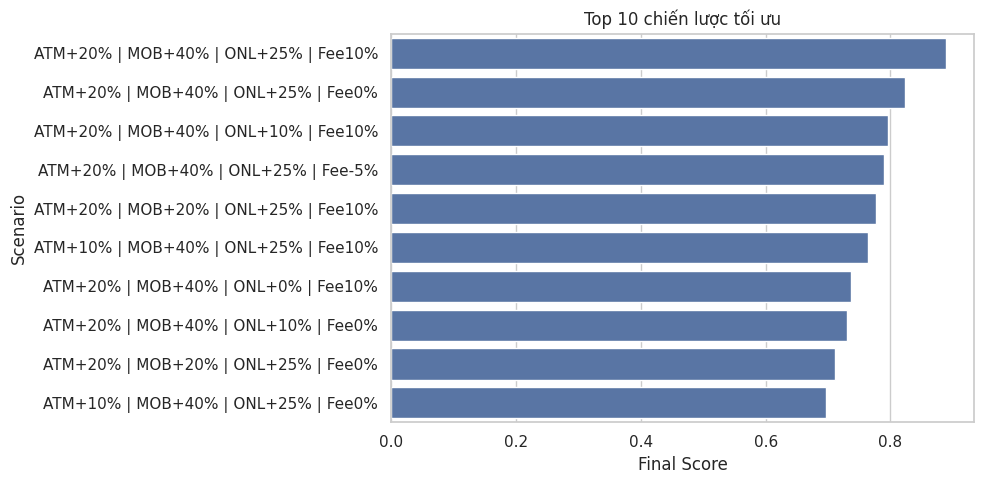


RECOMMENDATION

========== PRESCRIPTIVE ANALYTICS ==========
Chiến lược kinh doanh tối ưu:

1. ATM
   → Mở rộng quy mô giao dịch ATM:+20%


2. Mobile Banking
   → Đầu tư phát triển Mobile Banking:+40%


3. Online Banking
   → Khuyến khích giao dịch Online:+25%


4. Chính sách phí
   → Điều chỉnh Fee:+10%


Đánh giá tác động:

Final Score:
0.889

Mục tiêu tối ưu:
✓ Transaction Volume
✓ Channel Revenue
✓ Branch Performance

=> Khuyến nghị ngân hàng ưu tiên chiến lược
phát triển kênh số kết hợp mở rộng ATM.



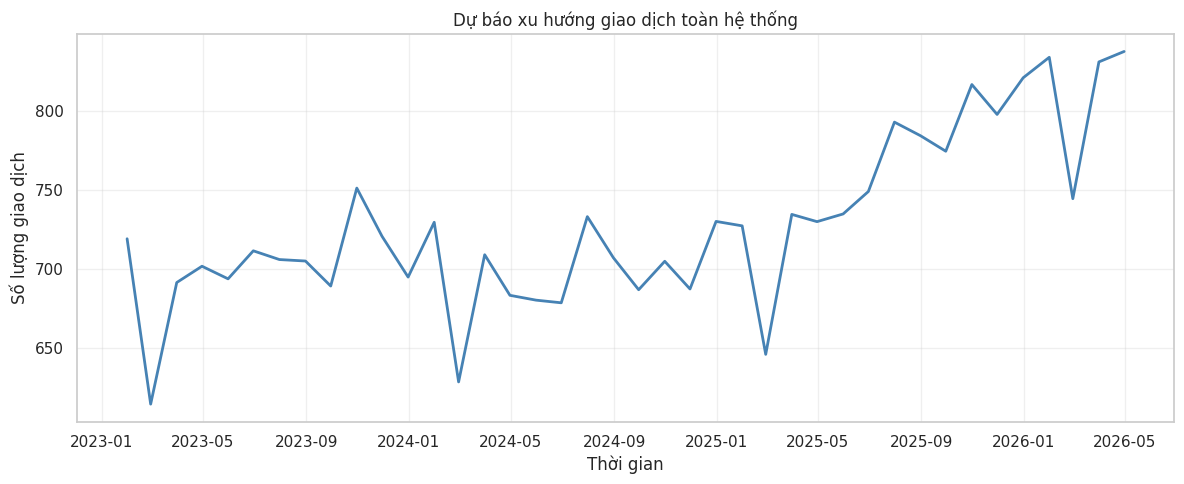

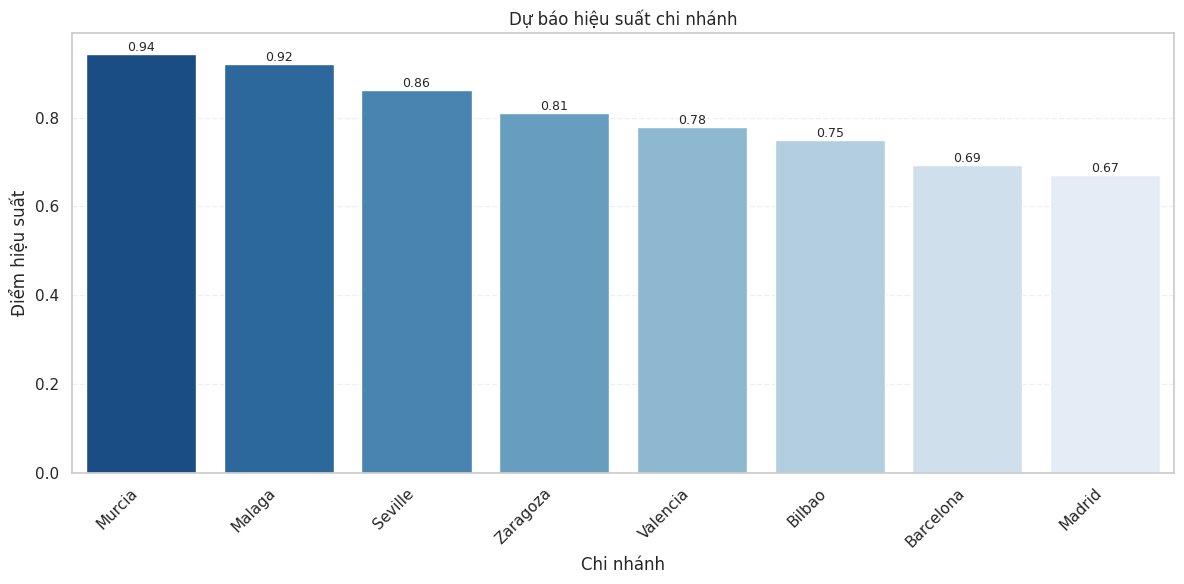

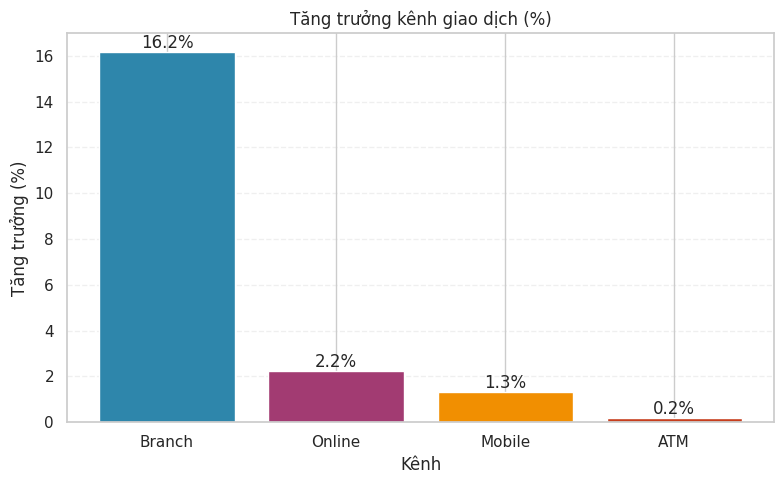


TOP 10 STRATEGIES


,ATM,Mobile,Online,Fee,VolumeNorm,RevenueNorm,BranchNorm,FeeRevenueNorm,FinalScore
80,0.2,0.4,0.25,0.10,1.000,1.000,0.447,1.000,0.889
79,0.2,0.4,0.25,0.00,1.000,1.000,0.447,0.333,0.823
77,0.2,0.4,0.10,0.10,0.830,0.830,0.578,1.000,0.797
78,0.2,0.4,0.25,-0.05,1.000,1.000,0.447,0.000,0.789
71,0.2,0.2,0.25,0.10,0.756,0.757,0.740,1.000,0.777
53,0.1,0.4,0.25,0.10,0.886,0.884,0.221,1.000,0.764
74,0.2,0.4,0.00,0.10,0.716,0.717,0.677,1.000,0.737
76,0.2,0.4,0.10,0.00,0.830,0.830,0.578,0.333,0.730
70,0.2,0.2,0.25,0.00,0.756,0.757,0.740,0.333,0.711
52,0.1,0.4,0.25,0.00,0.886,0.884,0.221,0.333,0.697


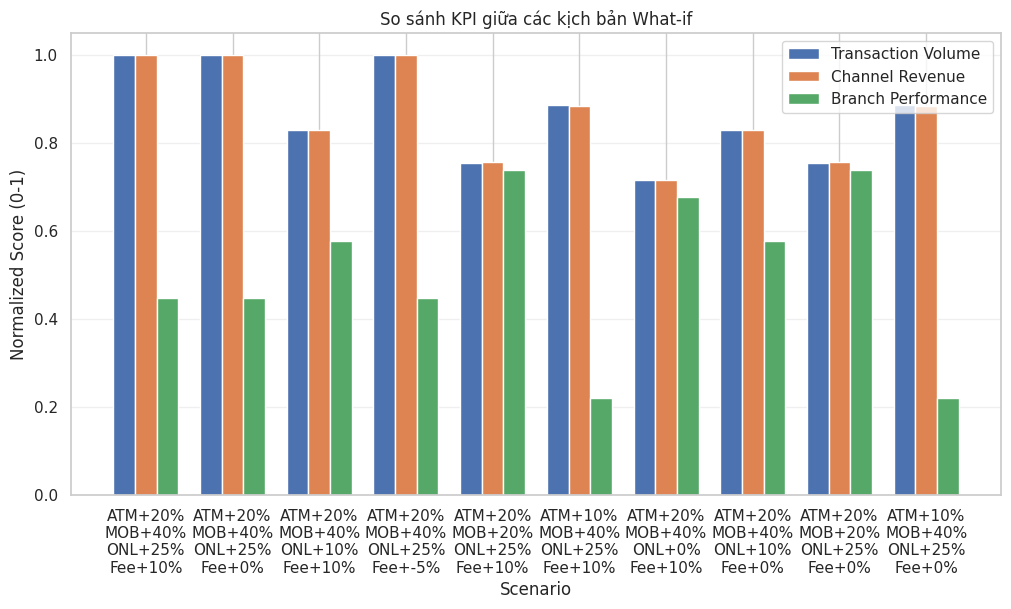

Đã xuất file thành công: Banking_Analytics_Result.xlsx


In [ ]:
#MỨC 3: 1,2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import logging

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').disabled = True

sns.set(style="whitegrid")

# =========================
# 1. LOAD DATA
# =========================
file_path = '/content/Banking_Transactional_Dataset.xlsx'
df = pd.read_excel(file_path)

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# =========================
# 2. REMOVE INCOMPLETE MONTH (05/2025)
# =========================
df = df[~(
    (df['TransactionDate'].dt.year == 2025) &
    (df['TransactionDate'].dt.month == 5)
)]

# =========================
# 3. FEATURE ENGINEERING
# =========================
df['FeeRevenue'] = df['Amount'] * 0.02
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

# =========================
# 4. GLOBAL FORECAST
# =========================
monthly_volume = df.groupby(
    pd.Grouper(key='TransactionDate', freq='ME')
).size().reset_index(name='Volume')

forecast_data = monthly_volume.rename(columns={'TransactionDate': 'ds', 'Volume': 'y'})

model_global = Prophet()
model_global.fit(forecast_data)

future_global = model_global.make_future_dataframe(periods=12, freq='ME')
forecast_global = model_global.predict(future_global)

# =========================
# 5. BRANCH PERFORMANCE SCORE (WITH FEE REVENUE)
# =========================
branch_monthly = df.groupby(
    ['BranchCity', pd.Grouper(key='TransactionDate', freq='ME')]
).agg({
    'TransactionID': 'count',
    'Amount': 'sum',
    'FeeRevenue': 'sum'
}).reset_index()

branch_monthly.columns = ['BranchCity', 'Date', 'Volume', 'Amount', 'FeeRevenue']

# Normalize
branch_monthly['VolumeNorm'] = branch_monthly['Volume'] / branch_monthly['Volume'].max()
branch_monthly['RevenueNorm'] = branch_monthly['Amount'] / branch_monthly['Amount'].max()
branch_monthly['FeeNorm'] = branch_monthly['FeeRevenue'] / branch_monthly['FeeRevenue'].max()

branch_monthly['BranchPerformance'] = (
    0.4 * branch_monthly['VolumeNorm'] +
    0.4 * branch_monthly['RevenueNorm'] +
    0.2 * branch_monthly['FeeNorm']
)

# =========================
# 6. BRANCH FORECAST
# =========================
cities = branch_monthly['BranchCity'].unique()

branch_result = []

for city in cities:

    data = branch_monthly[branch_monthly['BranchCity'] == city][['Date', 'BranchPerformance']]
    data = data.rename(columns={'Date': 'ds', 'BranchPerformance': 'y'}).dropna()

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=12, freq='ME')
    forecast = model.predict(future)

    branch_result.append({
        'BranchCity': city,
        'ForecastPerformance': forecast['yhat'].iloc[-1]
    })

branch_result = pd.DataFrame(branch_result).sort_values('ForecastPerformance', ascending=False)

# =========================
# 7. CHANNEL FORECAST
# =========================
channel_monthly = df.groupby(
    ['Channel', pd.Grouper(key='TransactionDate', freq='ME')]
).size().reset_index(name='Volume')

channels = channel_monthly['Channel'].unique()

channel_result = []

for ch in channels:

    data = channel_monthly[channel_monthly['Channel'] == ch][['TransactionDate', 'Volume']]
    data = data.rename(columns={'TransactionDate': 'ds', 'Volume': 'y'})

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=12, freq='ME')
    forecast = model.predict(future)

    current = data['y'].tail(12).mean()
    future_avg = forecast['yhat'].tail(12).mean()

    growth = 0 if current == 0 else (future_avg - current) / current * 100

    channel_result.append({
        'Channel': ch,
        'GrowthRate': growth,
        'ForecastVolume': future_avg
    })

channel_result = pd.DataFrame(channel_result).sort_values('GrowthRate', ascending=False)

# =====================================================
# 8. WHAT-IF ANALYSIS + SIMULATION ANALYTICS
# =====================================================

scenarios = []

atm_growth = [0, 0.1, 0.2]
mobile_growth = [0, 0.2, 0.4]
online_growth = [0, 0.1, 0.25]
fee_change = [-0.05, 0, 0.1]

for atm in atm_growth:
    for mobile in mobile_growth:
        for online in online_growth:
            for fee in fee_change:

                temp = df.copy()

                # =========================
                # Transaction Volume
                # =========================

                temp['VolumeFactor'] = temp['Channel'].map({
                    'ATM': 1 + atm,
                    'Mobile': 1 + mobile,
                    'Online': 1 + online
                }).fillna(1)

                # số lượng giao dịch mô phỏng
                temp['SimVolume'] = temp['VolumeFactor']

                total_volume = temp['SimVolume'].sum()

                # =========================
                # Revenue
                # =========================

                temp['SimRevenue'] = (
                    temp['Amount']
                    * temp['VolumeFactor']
                )
                temp['SimFee'] = (
                    temp['FeeRevenue']
                    * (1 + fee)
                )

                total_revenue = temp['SimRevenue'].sum()
                total_fee_revenue = temp['SimFee'].sum()

                # =========================
                # =========================
                # Branch Performance
                # =========================

                branch_perf = temp.groupby('BranchCity').agg({
                    'SimVolume': 'sum',
                    'SimRevenue': 'sum',
                    'SimFee': 'sum'
                }).reset_index()

                branch_perf['VolumeNorm'] = (
                    branch_perf['SimVolume']
                    - branch_perf['SimVolume'].min()
                ) / (
                    branch_perf['SimVolume'].max()
                    - branch_perf['SimVolume'].min()
                )

                branch_perf['RevenueNorm'] = (
                    branch_perf['SimRevenue']
                    - branch_perf['SimRevenue'].min()
                ) / (
                    branch_perf['SimRevenue'].max()
                    - branch_perf['SimRevenue'].min()
                )

                branch_perf['FeeNorm'] = (
                    branch_perf['SimFee']
                    - branch_perf['SimFee'].min()
                ) / (
                    branch_perf['SimFee'].max()
                    - branch_perf['SimFee'].min()
                )

                branch_perf['Score'] = (
                    0.4 * branch_perf['VolumeNorm']
                    + 0.4 * branch_perf['RevenueNorm']
                    + 0.2 * branch_perf['FeeNorm']
                )

                avg_branch_score = branch_perf['Score'].mean()

                scenarios.append({
                  'ATM': atm,
                  'Mobile': mobile,
                  'Online': online,
                  'Fee': fee,
                  'TotalVolume': total_volume,
                  'TotalRevenue': total_revenue,
                  'TotalFeeRevenue': total_fee_revenue,
                  'BranchScore': avg_branch_score
              })

simulation_df = pd.DataFrame(scenarios)
print(simulation_df.head())

# =====================================================
# KPI NORMALIZATION
# =====================================================

simulation_df['VolumeNorm'] = (
    simulation_df['TotalVolume']
    - simulation_df['TotalVolume'].min()
) / (
    simulation_df['TotalVolume'].max()
    - simulation_df['TotalVolume'].min()
)

simulation_df['RevenueNorm'] = (
    simulation_df['TotalRevenue']
    - simulation_df['TotalRevenue'].min()
) / (
    simulation_df['TotalRevenue'].max()
    - simulation_df['TotalRevenue'].min()
)

simulation_df['BranchNorm'] = (
    simulation_df['BranchScore']
    - simulation_df['BranchScore'].min()
) / (
    simulation_df['BranchScore'].max()
    - simulation_df['BranchScore'].min()
)
simulation_df['FeeRevenueNorm'] = (
    simulation_df['TotalFeeRevenue']
    - simulation_df['TotalFeeRevenue'].min()
) / (
    simulation_df['TotalFeeRevenue'].max()
    - simulation_df['TotalFeeRevenue'].min()
)
# =====================================================
# FINAL SCORE
# =====================================================

simulation_df['FinalScore'] = (
    0.35 * simulation_df['VolumeNorm']
    + 0.35 * simulation_df['RevenueNorm']
    + 0.20 * simulation_df['BranchNorm']
    + 0.10 * simulation_df['FeeRevenueNorm']
)

simulation_df = simulation_df.sort_values(
    'FinalScore',
    ascending=False
)

plt.figure(figsize=(10,5))

top10 = simulation_df.head(10).copy()

top10['Scenario'] = top10.apply(
    lambda x:
    f"ATM+{int(x['ATM']*100)}% | "
    f"MOB+{int(x['Mobile']*100)}% | "
    f"ONL+{int(x['Online']*100)}% | "
    f"Fee{int(x['Fee']*100)}%",
    axis=1
)

sns.barplot(
    data=top10,
    x='FinalScore',
    y='Scenario'
)
plt.title("Top 10 chiến lược tối ưu")
plt.xlabel("Final Score")
plt.ylabel("Scenario")
plt.tight_layout()
plt.show()
# =========================
# 10. PRESCRIPTIVE ANALYTICS
# =========================
best_strategy = simulation_df.iloc[0]

print("\nRECOMMENDATION")

print(
f"""
========== PRESCRIPTIVE ANALYTICS ==========
Chiến lược kinh doanh tối ưu:

1. ATM
   → Mở rộng quy mô giao dịch ATM:+{best_strategy['ATM']*100:.0f}%


2. Mobile Banking
   → Đầu tư phát triển Mobile Banking:+{best_strategy['Mobile']*100:.0f}%


3. Online Banking
   → Khuyến khích giao dịch Online:+{best_strategy['Online']*100:.0f}%


4. Chính sách phí
   → Điều chỉnh Fee:+{best_strategy['Fee']*100:.0f}%


Đánh giá tác động:

Final Score:
{best_strategy['FinalScore']:.3f}

Mục tiêu tối ưu:
✓ Transaction Volume
✓ Channel Revenue
✓ Branch Performance

=> Khuyến nghị ngân hàng ưu tiên chiến lược
phát triển kênh số kết hợp mở rộng ATM.
"""
)
# =========================
# 11. VISUALIZATION (CLEAR + BUSINESS STYLE)
# =========================

# Global forecast
plt.figure(figsize=(12,5))

plt.plot(
    forecast_global['ds'],
    forecast_global['yhat'],
    linewidth=2,
    color='steelblue'
)

plt.title("Dự báo xu hướng giao dịch toàn hệ thống")
plt.xlabel("Thời gian")
plt.ylabel("Số lượng giao dịch")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Branch performance
plt.figure(figsize=(12,6))

branch_sorted = branch_result.sort_values('ForecastPerformance', ascending=False)

ax = sns.barplot(
    data=branch_sorted,
    x='BranchCity',
    y='ForecastPerformance',
    hue='BranchCity',
    palette='Blues_r',
    legend=False
)

plt.title("Dự báo hiệu suất chi nhánh")
plt.xlabel("Chi nhánh")
plt.ylabel("Điểm hiệu suất")

plt.xticks(rotation=45, ha='right')

# label rõ hơn
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Channel growth
plt.figure(figsize=(8,5))

channel_sorted = channel_result.sort_values('GrowthRate', ascending=False)

bars = plt.bar(
    channel_sorted['Channel'],
    channel_sorted['GrowthRate'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
)

plt.title("Tăng trưởng kênh giao dịch (%)")
plt.xlabel("Kênh")
plt.ylabel("Tăng trưởng (%)")

plt.xticks(rotation=0)

for b in bars:
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.1f}%",
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
# Simulation
# ====================================
# TOP 10 SCENARIOS
# ====================================
print("\nTOP 10 STRATEGIES")

top = simulation_df.head(10).copy()

top_display = top[
    [
        'ATM',
        'Mobile',
        'Online',
        'Fee',
        'VolumeNorm',
        'RevenueNorm',
        'BranchNorm',
        'FeeRevenueNorm',
        'FinalScore'
    ]
].round(3)

display(top_display)
top['Scenario'] = top.apply(
    lambda x:
    f"ATM+{int(x['ATM']*100)}%\n"
    f"MOB+{int(x['Mobile']*100)}%\n"
    f"ONL+{int(x['Online']*100)}%\n"
    f"Fee+{int(x['Fee']*100)}%",
    axis=1
)

plt.figure(figsize=(12,6))

x = np.arange(len(top))
w = 0.25

plt.bar(
    x-w,
    top['VolumeNorm'],
    width=w,
    label='Transaction Volume'
)

plt.bar(
    x,
    top['RevenueNorm'],
    width=w,
    label='Channel Revenue'
)

plt.bar(
    x+w,
    top['BranchNorm'],
    width=w,
    label='Branch Performance'
)

plt.xticks(x, top['Scenario'])

plt.ylabel('Normalized Score (0-1)')
plt.xlabel('Scenario')
plt.title('So sánh KPI giữa các kịch bản What-if')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


# 1. Tính toán Revenue Forecast (Doanh thu dự báo)
# Giả định doanh thu mỗi giao dịch là trung bình cộng của dữ liệu gốc
avg_revenue_per_tx = df['FeeRevenue'].sum() / df['TransactionID'].count()

# Tạo dataframe doanh thu dự báo từ kết quả dự báo toàn hệ thống (forecast_global)
revenue_forecast = forecast_global[['ds', 'yhat']].copy()
revenue_forecast['ForecastRevenue'] = revenue_forecast['yhat'] * avg_revenue_per_tx
revenue_forecast.columns = ['Date', 'ForecastVolume', 'ForecastRevenue']

# 2. Lưu tất cả vào file Excel
with pd.ExcelWriter("Banking_Analytics_Result.xlsx") as writer:
    # Kết quả mô phỏng What-If
    simulation_df.to_excel(writer, sheet_name="WhatIf", index=False)

    # Kết quả dự báo chi nhánh
    branch_result.to_excel(writer, sheet_name="BranchForecast", index=False)

    # Kết quả dự báo kênh
    channel_result.to_excel(writer, sheet_name="ChannelForecast", index=False)

    # Kết quả doanh thu dự báo
    revenue_forecast.to_excel(writer, sheet_name="RevenueForecast", index=False)

print("Đã xuất file thành công: Banking_Analytics_Result.xlsx")




--- Đang khởi tạo và tính toán SHAP Values cho mô hình XGBoost ---


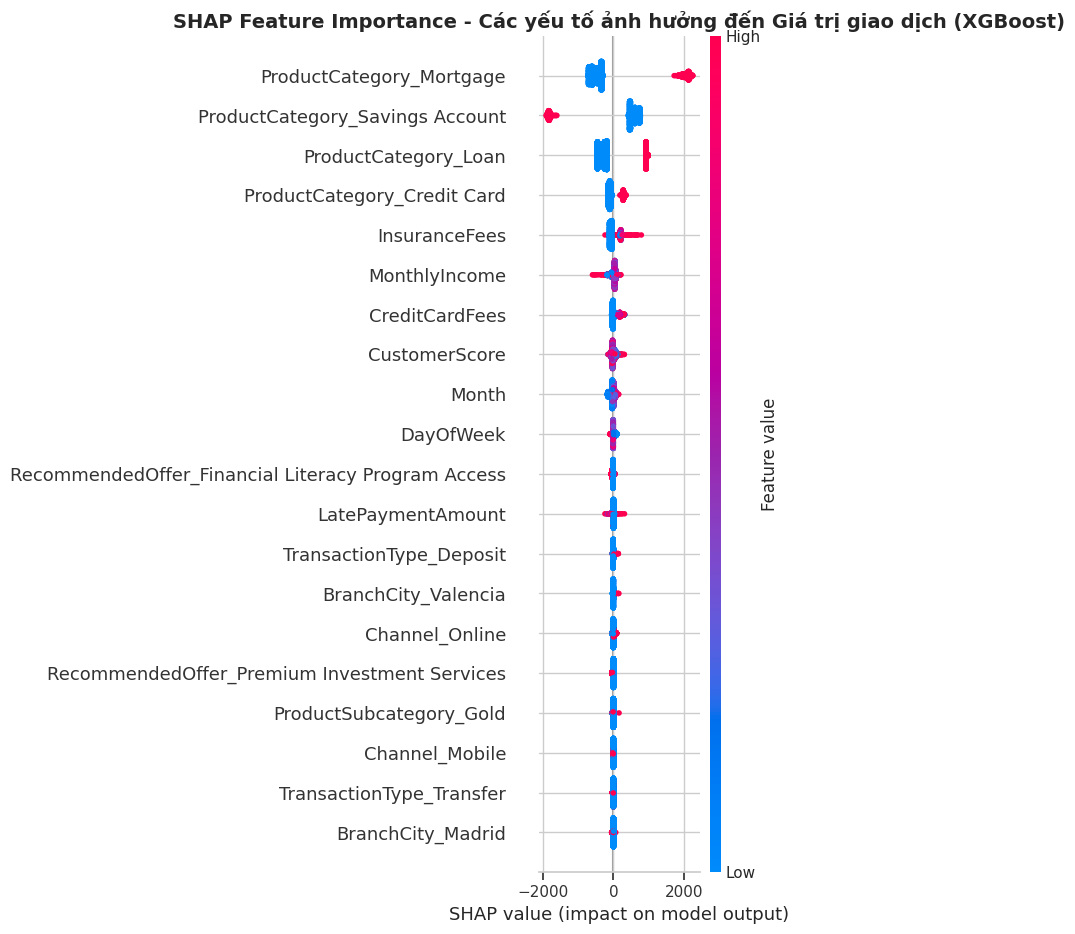

>>> Đã hoàn thành biểu đồ SHAP giải thích mô hình.


In [ ]:
#MỨC 3: 3,4
# =====================================================================
# EXPLAINABLE AI - SHAP FEATURE IMPORTANCE
# =====================================================================
import shap

print("\n--- Đang khởi tạo và tính toán SHAP Values cho mô hình XGBoost ---")

# 1. Khởi tạo bộ giải thích SHAP cho mô hình dạng cây (XGBoost)
explainer = shap.TreeExplainer(best_xgb)

# 2. Tính toán giá trị SHAP trên tập dữ liệu kiểm thử đã chuẩn hóa
# Để tốc độ tính toán nhanh hơn, sử dụng tập X_test_scaled
shap_values = explainer(X_test_scaled)

# 3. Trực quan hóa mức độ và hướng ảnh hưởng của các đặc trưng
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Summary Plot (Hiển thị tên đặc trưng gốc từ X_encoded)
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_encoded.columns,
    show=False
)

plt.title("SHAP Feature Importance - Các yếu tố ảnh hưởng đến Giá trị giao dịch (XGBoost)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(">>> Đã hoàn thành biểu đồ SHAP giải thích mô hình.")

In [ ]:
#MỨC 3: 3,4
# =====================================================================
# Đ4: WEB DASHBOARD
# =====================================================================
import gradio as gr
import pandas as pd
import numpy as np

# Sử dụng mã hóa Python Escape cho Emoji màu vàng hệ thống để code nhìn sạch và không lỗi font
ICON_WARN_YELLOW = "\u26A0\uFE0F"  # Ép trình duyệt render icon ⚠️ thành màu vàng chuẩn
ICON_WAIT = "\U0001F504"          # Vòng xoay tiến trình

# Hàm xử lý quét dữ liệu logic What-If thật từ tệp Excel
def mo_phong_chien_luoc_real(atm, mobile, online, fee):
    if fee is None or fee == "":
        # Khung thông báo lỗi HTML tổng thể bên dưới vẫn giữ màu đỏ uy tín
        error_html = """
        <div style="background-color: #fde8e8; border: 1px solid #f8b4b4; padding: 15px; border-radius: 8px; color: #9b1c1c; font-family: 'Segoe UI', Arial, sans-serif; margin-top: 15px;">
            <strong style="font-size: 14px;">&#9888; THÔNG BÁO HỆ THỐNG:</strong>
            <p style="margin: 5px 0 0 0; font-size: 13px;">Vui lòng xác định <b>Chính sách điều chỉnh phí dịch vụ</b> tại bảng cấu hình trước khi tiến hành thực hiện mô phỏng kịch bản.</p>
        </div>
        """
        #CẢNH BÁO VÀNG
        return f"{ICON_WARN_YELLOW} Khuyết", f"{ICON_WARN_YELLOW} Khuyết", f"{ICON_WARN_YELLOW} Khuyết", f"{ICON_WARN_YELLOW} Khuyết", error_html

    try:
        df_wi = pd.read_excel("Banking_Analytics_Result.xlsx", sheet_name="WhatIf")
        df_wi['ATM'] = df_wi['ATM'].round(2)
        df_wi['Mobile'] = df_wi['Mobile'].round(2)
        df_wi['Online'] = df_wi['Online'].round(2)
        df_wi['Fee'] = df_wi['Fee'].round(2)

        atm_val = round(atm, 2)
        mob_val = round(mobile, 2)
        onl_val = round(online, 2)
        fee_val = round(float(fee), 2)

        matched = df_wi[
            (df_wi['ATM'] == atm_val) &
            (df_wi['Mobile'] == mob_val) &
            (df_wi['Online'] == onl_val) &
            (df_wi['Fee'] == fee_val)
        ]

        if not matched.empty:
            res = matched.iloc[0]
            score_val = f"{res['FinalScore']:.3f}"
        else:
            df_wi['Distance'] = (df_wi['ATM'] - atm_val).abs() + (df_wi['Mobile'] - mob_val).abs() + (df_wi['Online'] - onl_val).abs() + (df_wi['Fee'] - fee_val).abs()
            res = df_wi.sort_values(by='Distance').iloc[0]
            score_val = f"{res['FinalScore']:.3f} (Nội suy)"

        success_html = f"""
        <div style="background-color: #ecfdf5; border: 1px solid #a7f3d0; padding: 15px; border-radius: 8px; color: #065f46; text-align: center; font-family: 'Segoe UI', Arial, sans-serif; margin-top: 15px;">
            <span style="font-size: 15px; font-weight: bold;">&#127942; CHỈ SỐ ĐÁNH GIÁ CHIẾN LƯỢC TỔNG HỢP (FINAL SCORE): {score_val}</span>
        </div>
        """
        return f"{res['TotalVolume']:.0f} GD", f"${res['TotalRevenue']:,.2f}", f"${res['TotalFeeRevenue']:,.2f}", f"{res['BranchScore']:.3f}", success_html

    except Exception as e:
        err_box = f'<div style="color: red; padding: 10px;">&#9888; Lỗi hệ thống: {str(e)}</div>'
        return "ERROR", "ERROR", "ERROR", "ERROR", err_box

# Hàm xử lý xóa bộ lọc (Reset)
def xoa_tat_ca_bo_loc():
    default_html = """
    <div style="background-color: #f8f9fa; border: 1px solid #e5e7eb; padding: 15px; border-radius: 8px; color: #4b5563; text-align: center; font-family: 'Segoe UI', Arial, sans-serif; margin-top: 15px;">
        <span>&#128259; Hệ thống đang ở trạng thái chờ kích hoạt tiến trình mô phỏng...</span>
    </div>
    """
    return [
        gr.update(value=0.0),
        gr.update(value=0.0),
        gr.update(value=0.0),
        gr.update(value=None),
        f"{ICON_WAIT} Đang chờ...",
        f"{ICON_WAIT} Đang chờ...",
        f"{ICON_WAIT} Đang chờ...",
        f"{ICON_WAIT} Đang chờ...",
        default_html
    ]

# ---------------------------------------------------------------------
# THIẾT KẾ GIAO DIỆN WEB BLOCKS
# ---------------------------------------------------------------------
with gr.Blocks(title="Banking Performance Dashboard", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # \U0001F4C8 Hệ Thống Dự Báo & Mô Phỏng Kịch Bản Chiến Lược Ngân Hàng
    *Nghiên cứu ứng dụng Prescriptive Analytics nhằm tối ưu hóa vận hành hệ thống số.*
    """)

    with gr.Row():
        # CỘT TRÁI (BẢNG ĐIỀU KHIỂN ĐẦU VÀO)
        with gr.Column(scale=1):
            gr.Markdown("### \U0001F3AF Cấu hình kịch bản (What-If)")
            atm_slider = gr.Slider(0, 0.2, step=0.05, value=0.0, label="Tăng trưởng quy mô kênh ATM")
            mobile_slider = gr.Slider(0, 0.4, step=0.1, value=0.0, label="Đầu tư phát triển Mobile Banking")
            online_slider = gr.Slider(0, 0.25, step=0.05, value=0.0, label="Khuyến khích Online Banking")

            fee_dropdown = gr.Dropdown([-0.05, 0.0, 0.1], value=None, label="Chính sách điều chỉnh phí dịch vụ", interactive=True)

            with gr.Row():
                btn_run = gr.Button("\U0001F680 CHẠY", variant="primary")
                btn_reset = gr.Button("\U0001F5D1 XÓA LỌC", variant="stop")

        # CỘT PHẢI (BẢNG KẾT QUẢ KPI)
        with gr.Column(scale=2):
            gr.Markdown("### \U0001F4CC Chỉ số kết quả đầu ra")

            with gr.Row():
                txt_volume = gr.Textbox(value=f"{ICON_WAIT} Đang chờ...", label="Tổng lượng giao dịch mô phỏng", interactive=False)
                txt_revenue = gr.Textbox(value=f"{ICON_WAIT} Đang chờ...", label="Doanh thu kênh (Channel Revenue)", interactive=False)

            with gr.Row():
                txt_fee = gr.Textbox(value=f"{ICON_WAIT} Đang chờ...", label="Doanh thu từ phí dịch vụ", interactive=False)
                txt_score = gr.Textbox(value=f"{ICON_WAIT} Đang chờ...", label="Điểm hiệu suất chi nhánh (Branch Score)", interactive=False)

            # Khung HTML kết quả cuối cùng
            html_final = gr.HTML(value="""
            <div style="background-color: #f8f9fa; border: 1px solid #e5e7eb; padding: 15px; border-radius: 8px; color: #4b5563; text-align: center; font-family: 'Segoe UI', Arial, sans-serif; margin-top: 15px;">
                <span>&#128259; Hệ thống đang ở trạng thái chờ kích hoạt tiến trình mô phỏng...</span>
            </div>
            """)

    # ĐĂNG KÝ SỰ KIỆN NÚT BẤM
    inputs_list = [atm_slider, mobile_slider, online_slider, fee_dropdown]
    outputs_list = [txt_volume, txt_revenue, txt_fee, txt_score, html_final]

    btn_run.click(mo_phong_chien_luoc_real, inputs=inputs_list, outputs=outputs_list)
    btn_reset.click(
        fn=xoa_tat_ca_bo_loc,
        inputs=[],
        outputs=[atm_slider, mobile_slider, online_slider, fee_dropdown, txt_volume, txt_revenue, txt_fee, txt_score, html_final]
    )

# Khởi chạy trang web độc lập full-tab
demo.launch(share=True, inline=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://812d7e129b6f4e1f8e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
